In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv("data/StudentsPerformance.csv")

In [3]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [7]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [ ]:
df.nunique()

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

In [14]:
# eda
print("categorical in race/ethnicity variables:  ",end="")
print(df['race/ethnicity'].unique())

print("categorical in gender variables:  ",end=" ")
print(df['gender'].unique())

print("categorical in parental level of education variables:  ",end=" ")
print(df['parental level of education'].unique())

print("categorical in test preparation course variables:  ",end=" ")
print(df['test preparation course'].unique())

categorical in race/ethnicity variables:  <StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str
categorical in gender variables:   <StringArray>
['female', 'male']
Length: 2, dtype: str
categorical in parental level of education variables:   <StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str
categorical in test preparation course variables:   <StringArray>
['none', 'completed']
Length: 2, dtype: str


In [17]:
numeric_feature=[feature for feature in df.columns if df[feature].dtype!="str"]
categ_features=[feature for feature in df.columns if df[feature].dtype=="str"]

print("we have {} numerical feature: {}".format(len(numeric_feature),numeric_feature))
print("we have {} categorical feature: {}".format(len(categ_features),categ_features))

we have 3 numerical feature: ['math score', 'reading score', 'writing score']
we have 5 categorical feature: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


In [19]:
df['total score']=df['math score'] + df['reading score'] + df['writing score']
df['average'] = df['total score']/3
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [22]:
reading_full=df[df['reading score']==100]['average'].count()
print(f"number of students with full marks in reading:{reading_full}")

writing_full=df[df['writing score']==100]['average'].count()
print(f"number of students with full marks in reading:{writing_full}")

math_full=df[df['math score']==100]['average'].count()
print(f"number of students with full marks in reading:{math_full}")

number of students with full marks in reading:17
number of students with full marks in reading:14
number of students with full marks in reading:7


In [24]:
reading_less_20=df[df['reading score']<=20]['average'].count()
writing_less_20=df[df['writing score']<=20]['average'].count()
math_less_20=df[df['math score']<=20]['average'].count()

print(f"number of students with less than 20 in maths:{math_less_20} ")
print(f"number of students with less than 20 in reading:{reading_less_20} ")
print(f"number of students with less than 20 in writng:{writing_less_20} ")

number of students with less than 20 in maths:4 
number of students with less than 20 in reading:1 
number of students with less than 20 in writng:3 


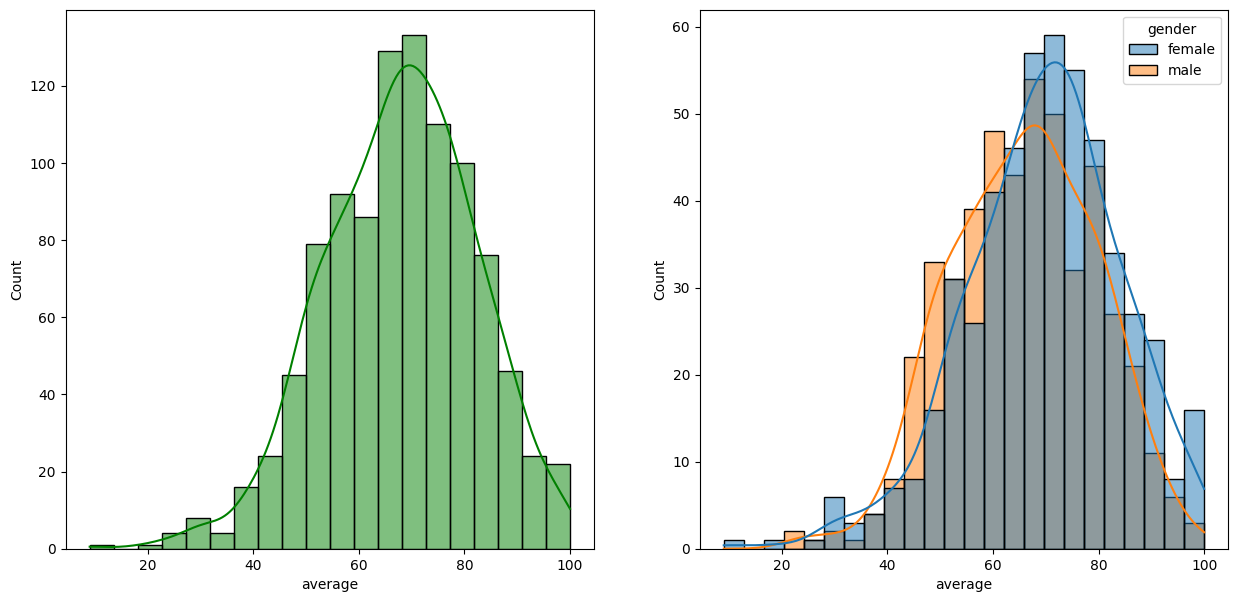

In [25]:
plt.subplots(1,2,figsize=(15,7))
plt.subplot(1,2,1)
sns.histplot(data=df,x='average',bins=20,kde=True,color='g')
plt.subplot(1,2,2)
sns.histplot(data=df,x='average',kde=True,hue='gender')
plt.show()

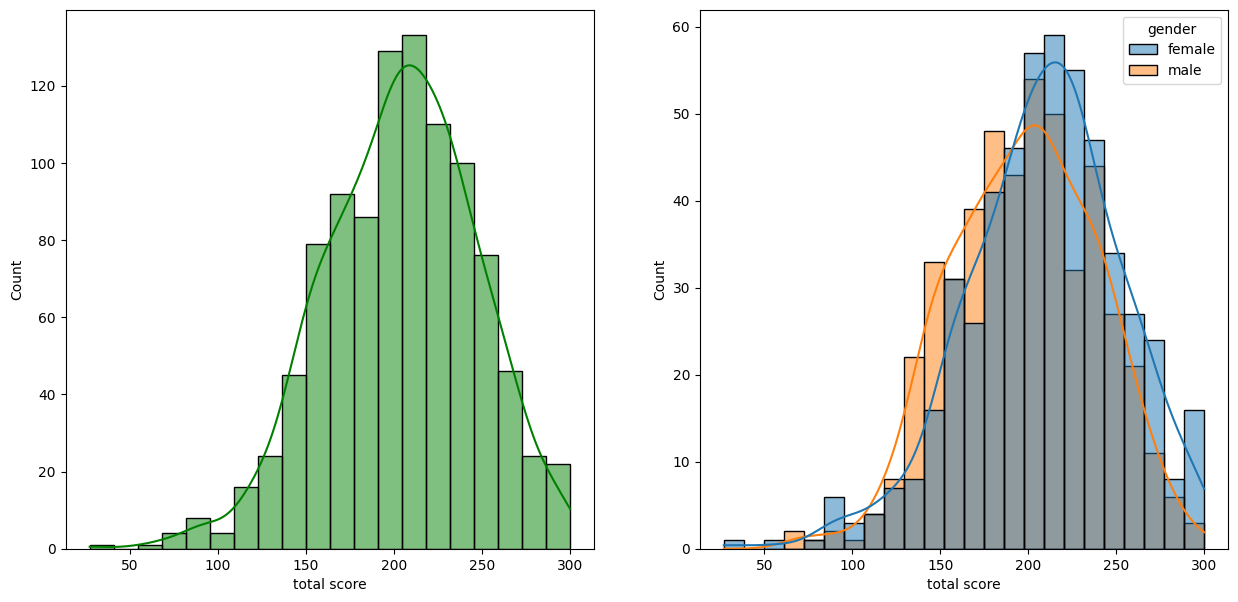

In [26]:
plt.subplots(1,2,figsize=(15,7))
plt.subplot(1,2,1)
sns.histplot(data=df,x='total score',bins=20,kde=True,color='g')
plt.subplot(1,2,2)
sns.histplot(data=df,x='total score',kde=True,hue='gender')
plt.show()

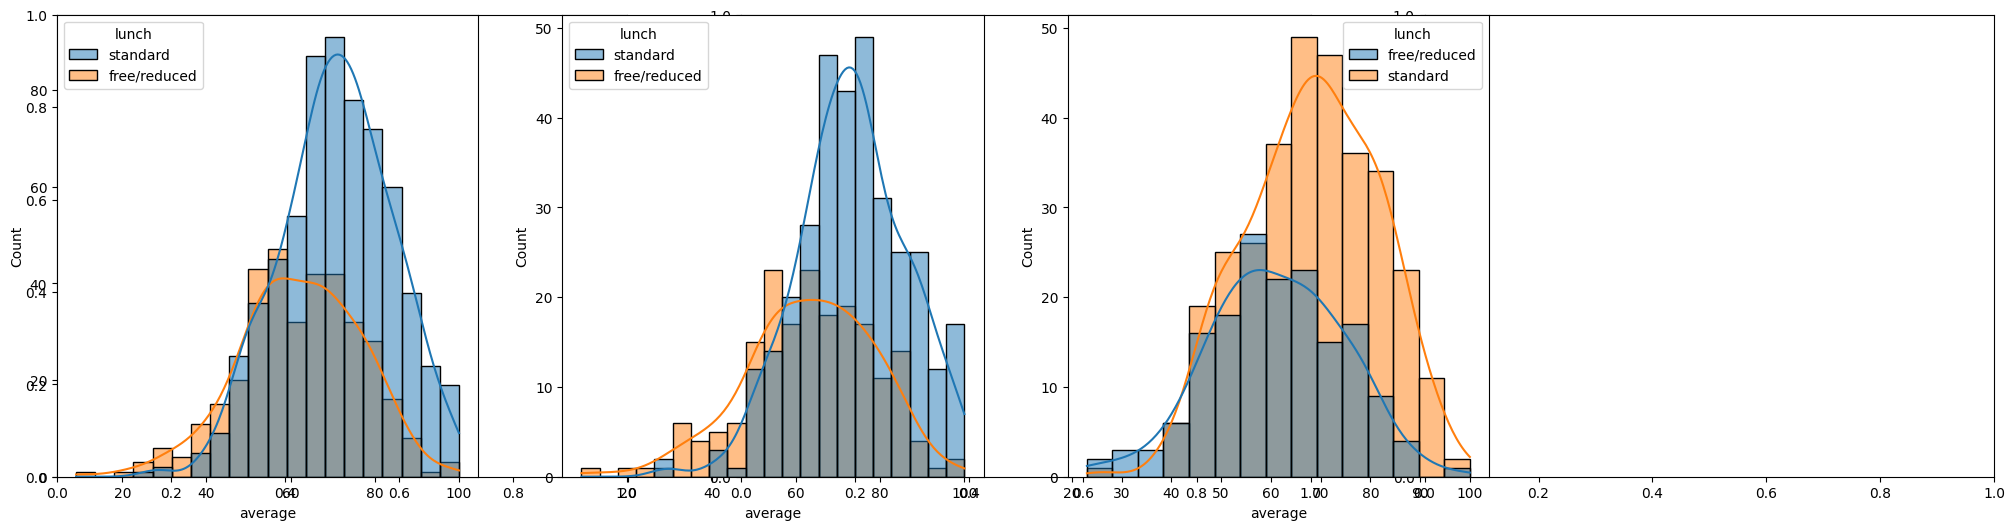

In [27]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(1,4,1)
sns.histplot(data=df,x='average',bins=20,kde=True,hue='lunch')
plt.subplot(1,4,2)
sns.histplot(data=df[df['gender']=='female'],x='average',kde=True,hue='lunch')
plt.subplot(1,4,3)
sns.histplot(data=df[df['gender']=='male'],x='average',kde=True,hue='lunch')
plt.show()